# Symbolic Triplet Coverage Analysis
Finds which Ruleformer-predicted symbolic triplets actually exist in the FinDKG dataset, then shows the distribution of **correctly predicted** triplets by relation type.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

## 1. Load Relation Mapping

In [2]:
relation_map = pd.read_csv(
    'FinDKG_dataset/FinDKG/relation2id.txt',
    sep='\t', header=None, names=['relation_name', 'relation_id']
)
id_to_relation = dict(zip(relation_map['relation_id'], relation_map['relation_name']))
print(f"{len(id_to_relation)} relations found:")
for rid, rname in sorted(id_to_relation.items()):
    print(f"  {rid}: {rname}")

15 relations found:
  0: Relate_To
  1: Control
  2: Operate_In
  3: Impact
  4: Has
  5: Negative_Impact_On
  6: Raise
  7: Is_Member_Of
  8: Participates_In
  9: Announce
  10: Invests_In
  11: Produce
  12: Introduce
  13: Decrease
  14: Positive_Impact_On


## 2. Load FinDKG Ground Truth (train + valid + test)

In [3]:
def load_findkg_split(path):
    df = pd.read_csv(path, sep='\t', header=None,
                     names=['head', 'relation', 'tail', 'time', 'flag'])
    return df[['head', 'relation', 'tail']]

findkg = pd.concat([
    load_findkg_split('FinDKG_dataset/FinDKG/train.txt'),
    load_findkg_split('FinDKG_dataset/FinDKG/valid.txt'),
    load_findkg_split('FinDKG_dataset/FinDKG/test.txt'),
], ignore_index=True).drop_duplicates()

# Build a set of (head, relation, tail) tuples for fast lookup
findkg_set = set(zip(findkg['head'], findkg['relation'], findkg['tail']))
print(f"FinDKG unique (h, r, t) triplets: {len(findkg_set):,}")

FinDKG unique (h, r, t) triplets: 97,417


## 3. Load Ruleformer Symbolic Predictions
Using `sym_triplets_20260430.csv` (latest). Switch to `FinDKG_dataset/FinDKG/sym_triplets.tsv` for the earlier version.

In [4]:
# --- Option A: latest predictions (sym_triplets_20260430.csv) ---
# Note: file uses TAB separators despite the .csv extension
sym = pd.read_csv(
    'sym_triplets_20260430.csv',
    sep='\t', header=None, names=['head', 'relation', 'tail', 'time_group']
)

# --- Option B: older predictions (uncomment to switch) ---
# sym = pd.read_csv(
#     'FinDKG_dataset/FinDKG/sym_triplets.tsv',
#     sep='\t', header=None, names=['head', 'relation', 'tail']
# )

sym = sym[['head', 'relation', 'tail']].drop_duplicates()
print(f"Symbolic predictions (unique h,r,t): {len(sym):,}")

Symbolic predictions (unique h,r,t): 506,033


## 4. Find Correctly Predicted Triplets (present in FinDKG)

In [5]:
sym['in_findkg'] = [
    (h, r, t) in findkg_set
    for h, r, t in zip(sym['head'], sym['relation'], sym['tail'])
]

correct = sym[sym['in_findkg']].copy()

total_sym     = len(sym)
total_correct = len(correct)
overall_pct   = 100 * total_correct / total_sym

print(f"Total symbolic predictions       : {total_sym:,}")
print(f"Correctly predicted (in FinDKG)  : {total_correct:,}")
print(f"Overall coverage rate            : {overall_pct:.2f}%")

Total symbolic predictions       : 506,033
Correctly predicted (in FinDKG)  : 11,179
Overall coverage rate            : 2.21%


## 5. Distribution by Relation Type

In [6]:
# Map relation IDs to names
sym['relation_name']     = sym['relation'].map(id_to_relation)
correct['relation_name'] = correct['relation'].map(id_to_relation)

# --- Counts & percentages ---
all_counts     = sym.groupby('relation_name').size().rename('total_predicted')
correct_counts = correct.groupby('relation_name').size().rename('correctly_predicted')

summary = pd.concat([all_counts, correct_counts], axis=1).fillna(0).astype(int)
summary['coverage_%']        = (100 * summary['correctly_predicted'] / summary['total_predicted']).round(2)
summary['pct_of_all_correct'] = (100 * summary['correctly_predicted'] / total_correct).round(2)

summary = summary.sort_values('correctly_predicted', ascending=False)
summary.index.name = 'relation'

print(summary.to_string())

                    total_predicted  correctly_predicted  coverage_%  pct_of_all_correct
relation                                                                                
Impact                       145748                 3484        2.39               31.17
Operate_In                   150928                 3049        2.02               27.27
Control                       17826                 1113        6.24                9.96
Negative_Impact_On            48071                  769        1.60                6.88
Has                           13684                  528        3.86                4.72
Relate_To                      5135                  517       10.07                4.62
Raise                         13808                  309        2.24                2.76
Announce                      22918                  286        1.25                2.56
Positive_Impact_On            22604                  244        1.08                2.18
Is_Member_Of         

## 6. Visualisation

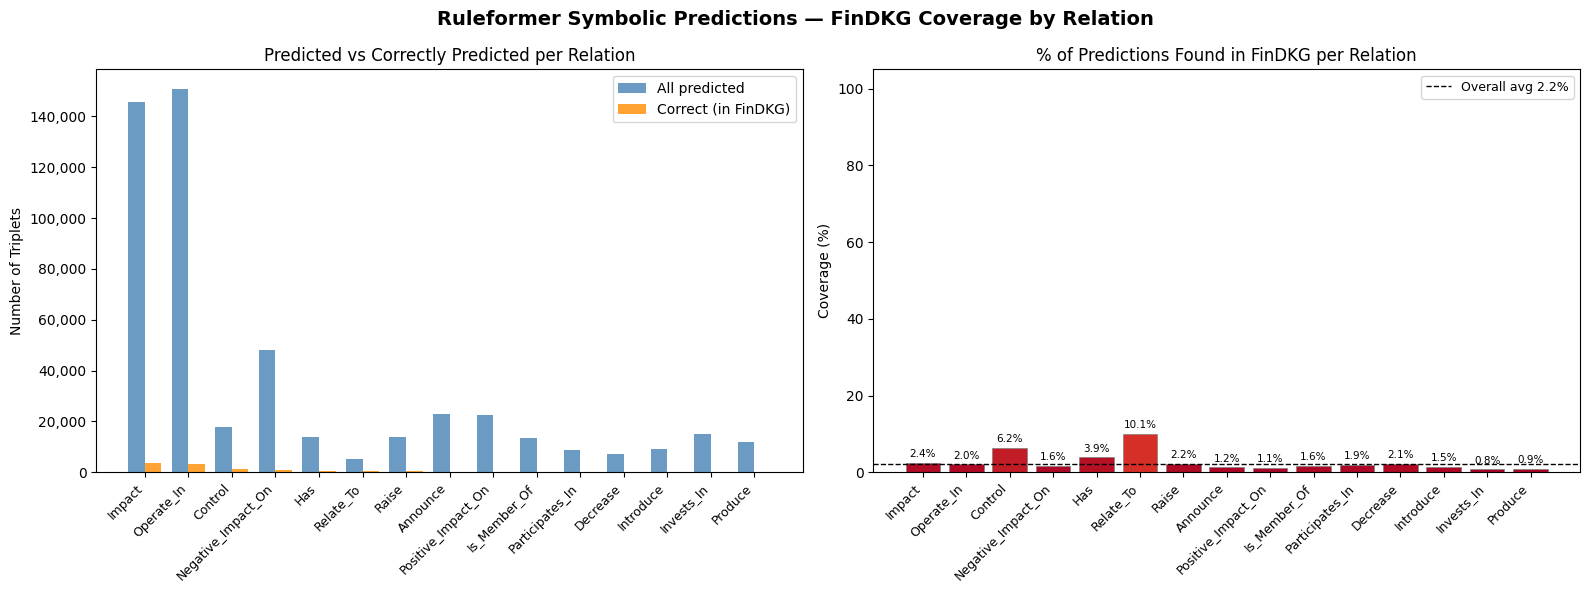

Figure saved to report/sym_triplets_coverage_by_relation.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ruleformer Symbolic Predictions — FinDKG Coverage by Relation', fontsize=14, fontweight='bold')

relations = summary.index.tolist()
x = np.arange(len(relations))

# --- Left: grouped bar (all predicted vs correctly predicted) ---
ax = axes[0]
w = 0.38
ax.bar(x - w/2, summary['total_predicted'],     width=w, label='All predicted',        color='steelblue',  alpha=0.8)
ax.bar(x + w/2, summary['correctly_predicted'],  width=w, label='Correct (in FinDKG)', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(relations, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Triplets')
ax.set_title('Predicted vs Correctly Predicted per Relation')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{int(v):,}'))

# --- Right: coverage rate (%) per relation ---
ax2 = axes[1]
colors = plt.cm.RdYlGn(summary['coverage_%'] / 100)
bars3 = ax2.bar(x, summary['coverage_%'], color=colors, edgecolor='grey', linewidth=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(relations, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Coverage (%)')
ax2.set_title('% of Predictions Found in FinDKG per Relation')
ax2.set_ylim(0, 105)
ax2.axhline(overall_pct, color='black', linestyle='--', linewidth=1, label=f'Overall avg {overall_pct:.1f}%')
ax2.legend(fontsize=9)
for bar, pct in zip(bars3, summary['coverage_%']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('report/sym_triplets_coverage_by_relation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to report/sym_triplets_coverage_by_relation.png')

## 7. Pie Chart — Distribution of *Correct* Predictions by Relation

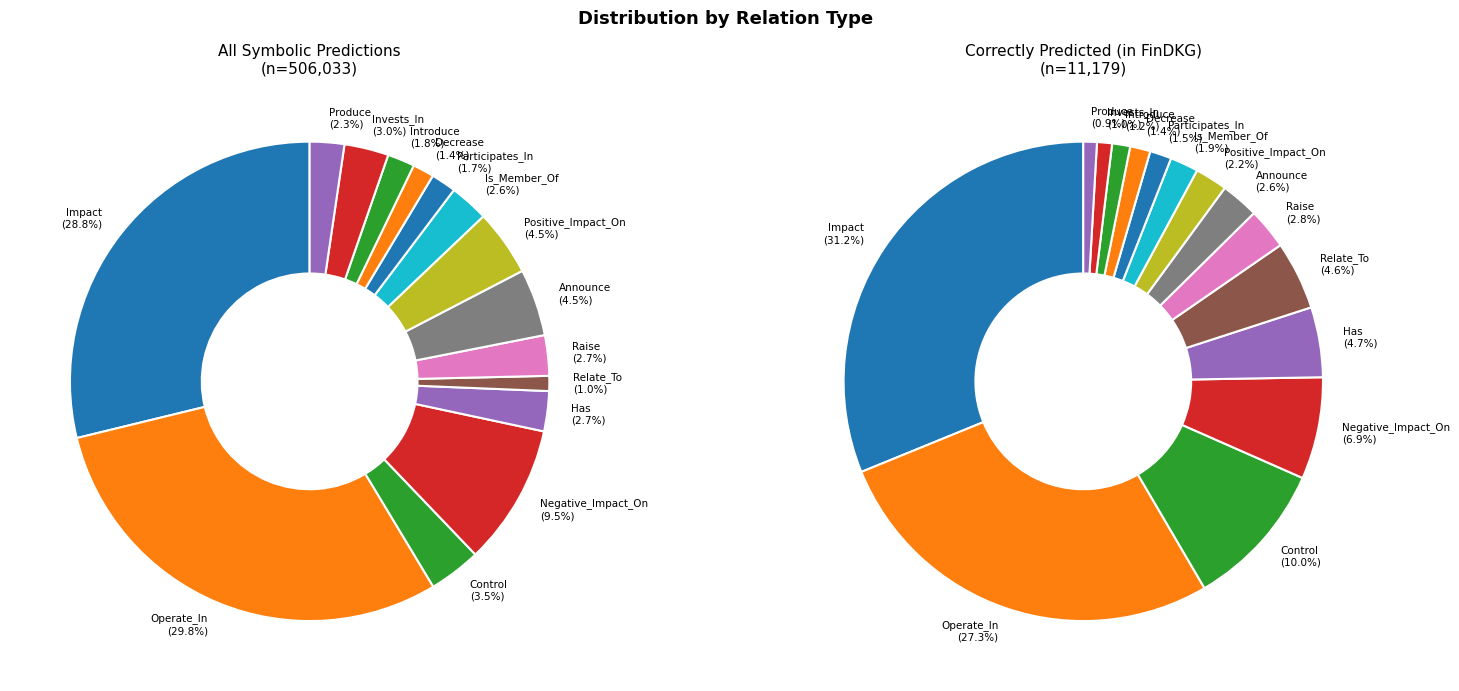

Figure saved to report/sym_triplets_pie_distribution.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Distribution by Relation Type', fontsize=13, fontweight='bold')

wedge_props = dict(width=0.55, edgecolor='white', linewidth=1.5)

for ax, col, title in [
    (axes[0], 'total_predicted',     'All Symbolic Predictions'),
    (axes[1], 'correctly_predicted', 'Correctly Predicted (in FinDKG)'),
]:
    data   = summary[col]
    labels = summary.index
    pcts   = 100 * data / data.sum()
    short_labels = [f'{l}\n({p:.1f}%)' for l, p in zip(labels, pcts)]
    ax.pie(data, labels=short_labels, wedgeprops=wedge_props,
           startangle=90, textprops={'fontsize': 7.5})
    ax.set_title(f'{title}\n(n={int(data.sum()):,})', fontsize=11)

plt.tight_layout()
plt.savefig('report/sym_triplets_pie_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to report/sym_triplets_pie_distribution.png')

## 8. Summary Table (LaTeX-ready)

In [20]:
latex_df = summary[['total_predicted', 'correctly_predicted', 'coverage_%', 'pct_of_all_correct']].copy()
latex_df.columns = ['All Predicted', 'Correctly Predicted', 'Coverage (\%)', '\% of All Correct']
print(latex_df.to_latex(caption='Distribution of correctly predicted symbolic triplets by relation type.',
                        label='tab:sym_coverage',
                        float_format='%.2f'))

\begin{table}
\caption{Distribution of correctly predicted symbolic triplets by relation type.}
\label{tab:sym_coverage}
\begin{tabular}{lrrrr}
\toprule
 & All Predicted & Correctly Predicted & Coverage (\%) & \% of All Correct \\
relation &  &  &  &  \\
\midrule
Impact & 145748 & 3484 & 2.39 & 31.17 \\
Operate_In & 150928 & 3049 & 2.02 & 27.27 \\
Control & 17826 & 1113 & 6.24 & 9.96 \\
Negative_Impact_On & 48071 & 769 & 1.60 & 6.88 \\
Has & 13684 & 528 & 3.86 & 4.72 \\
Relate_To & 5135 & 517 & 10.07 & 4.62 \\
Raise & 13808 & 309 & 2.24 & 2.76 \\
Announce & 22918 & 286 & 1.25 & 2.56 \\
Positive_Impact_On & 22604 & 244 & 1.08 & 2.18 \\
Is_Member_Of & 13275 & 213 & 1.60 & 1.91 \\
Participates_In & 8555 & 163 & 1.91 & 1.46 \\
Decrease & 7282 & 153 & 2.10 & 1.37 \\
Introduce & 9292 & 136 & 1.46 & 1.22 \\
Invests_In & 15138 & 113 & 0.75 & 1.01 \\
Produce & 11769 & 102 & 0.87 & 0.91 \\
\bottomrule
\end{tabular}
\end{table}



<>:2: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:2: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:2: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:2: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
/var/folders/n9/l4rv06vs4q9c0k1kyr946f0r0000gn/T/ipykernel_78816/18172525.py:2: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  latex_df.columns = ['All Predicted', 'Correctly Predicted', 'Coverage (\%)', '\% of All Correct']
/var/folders/n9/l4rv06vs4q9c0k1kyr946f0r0000gn/T/ipykernel_78